In [2]:
print(1)

1


![alt text](images/uspas.png)
# Basic Xsuite Example: FODO Cell, Twiss Parameters, and Matching

This notebook gives a compact first example of using [Xsuite](https://xsuite.readthedocs.io/) for transverse beam optics.

We will:

- build a simple FODO cell from drifts and quadrupoles,
- compute and display periodic Twiss parameters,
- change quadrupole settings and see the optics response,
- build two FODO cells with shared quadrupole knobs,
- match the two-cell lattice to a desired phase advance,
- track a small set of particles through the matched line.


## 1. Imports and Plot Style

Xsuite is split into packages. In this notebook we mainly use `xtrack` for lattice elements, Twiss calculations, matching, and tracking.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xtrack as xt

%config InlineBackend.figure_format = "retina"
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"xtrack version: {xt.__version__}")


xtrack version: 0.96.2


## 2. Build a FODO Cell

A FODO cell is a periodic focusing structure made from a focusing quadrupole (`QF`), a defocusing quadrupole (`QD`), and drifts. Here we use the sequence

\[
\frac{D}{2} - QF - D - QD - \frac{D}{2}.
\]

The helper below can build either one cell or many repeated cells. All `QF` magnets share the same knob `kqf`, and all `QD` magnets share `kqd`, which makes matching easy later.

In [4]:
def make_fodo_line(n_cells=1, *, drift_length=2.0, quad_length=0.20,
                   kqf=1.0, kqd=-1.0, p0c=1e9):
    """Return an Xsuite line containing n repeated FODO cells."""
    elements = []
    names = []

    for i_cell in range(n_cells):
        tag = f"c{i_cell + 1}"
        elements += [
            xt.Drift(length=drift_length / 2),
            xt.Quadrupole(length=quad_length, k1=0),
            xt.Drift(length=drift_length),
            xt.Quadrupole(length=quad_length, k1=0),
            xt.Drift(length=drift_length / 2),
        ]
        names += [f"d1_{tag}", f"qf_{tag}", f"d2_{tag}", f"qd_{tag}", f"d3_{tag}"]

    line = xt.Line(elements=elements, element_names=names)

    # Reference particle: 1 GeV/c protons.
    line.particle_ref = xt.Particles(
        p0c=p0c,
        mass0=xt.PROTON_MASS_EV,
        q0=1,
    )

    # Knobs used by all focusing and defocusing quadrupoles.
    line.vars["kqf"] = kqf
    line.vars["kqd"] = kqd
    for name in names:
        if name.startswith("qf_"):
            line.element_refs[name].k1 = line.vars["kqf"]
        elif name.startswith("qd_"):
            line.element_refs[name].k1 = line.vars["kqd"]

    line.build_tracker()
    return line


cell = make_fodo_line(n_cells=1, kqf=1.0, kqd=-1.0)
cell.element_names


('d1_c1', 'qf_c1', 'd2_c1', 'qd_c1', 'd3_c1')

## 3. Compute and Display Twiss Parameters

For this simple transverse example, `method="4d"` is sufficient. Xsuite reports phase advances `mux` and `muy` in units of turns. Multiply by \(2\pi\) for radians or by 360 for degrees.

In [5]:
tw_cell = cell.twiss(method="4d")

columns = ["name", "s", "betx", "bety", "alfx", "alfy", "mux", "muy"]
twiss_table = tw_cell.to_pandas()[columns]
twiss_table


,name,s,betx,bety,alfx,alfy,mux,muy
0,d1_c1,0.0,10.327470,10.327470,-1.055996,1.055996,0.000000,0.000000
1,qf_c1,1.0,12.644268,8.420284,-1.260802,0.851190,0.013945,0.017100
2,d2_c1,1.2,12.644268,8.420284,1.260802,-0.851190,0.016446,0.020906
3,qd_c1,3.2,8.420284,12.644268,0.851190,-1.260802,0.047492,0.051951
4,d3_c1,3.4,8.420284,12.644268,-0.851190,1.260802,0.051298,0.054452
5,_end_point,4.4,10.327470,10.327470,-1.055996,1.055996,0.068398,0.068398


In [6]:
summary = pd.DataFrame({
    "quantity": [
        "cell length [m]",
        "Qx per cell",
        "Qy per cell",
        "phase x [deg/cell]",
        "phase y [deg/cell]",
        "min betx [m]",
        "max betx [m]",
        "min bety [m]",
        "max bety [m]",
    ],
    "value": [
        tw_cell.s[-1],
        tw_cell.qx,
        tw_cell.qy,
        360 * tw_cell.qx,
        360 * tw_cell.qy,
        np.min(tw_cell.betx),
        np.max(tw_cell.betx),
        np.min(tw_cell.bety),
        np.max(tw_cell.bety),
    ],
})
summary


,quantity,value
0,cell length [m],4.400000
1,Qx per cell,0.068398
2,Qy per cell,0.068398
3,phase x [deg/cell],24.623104
4,phase y [deg/cell],24.623104
5,min betx [m],8.420284
6,max betx [m],12.644268
7,min bety [m],8.420284
8,max bety [m],12.644268


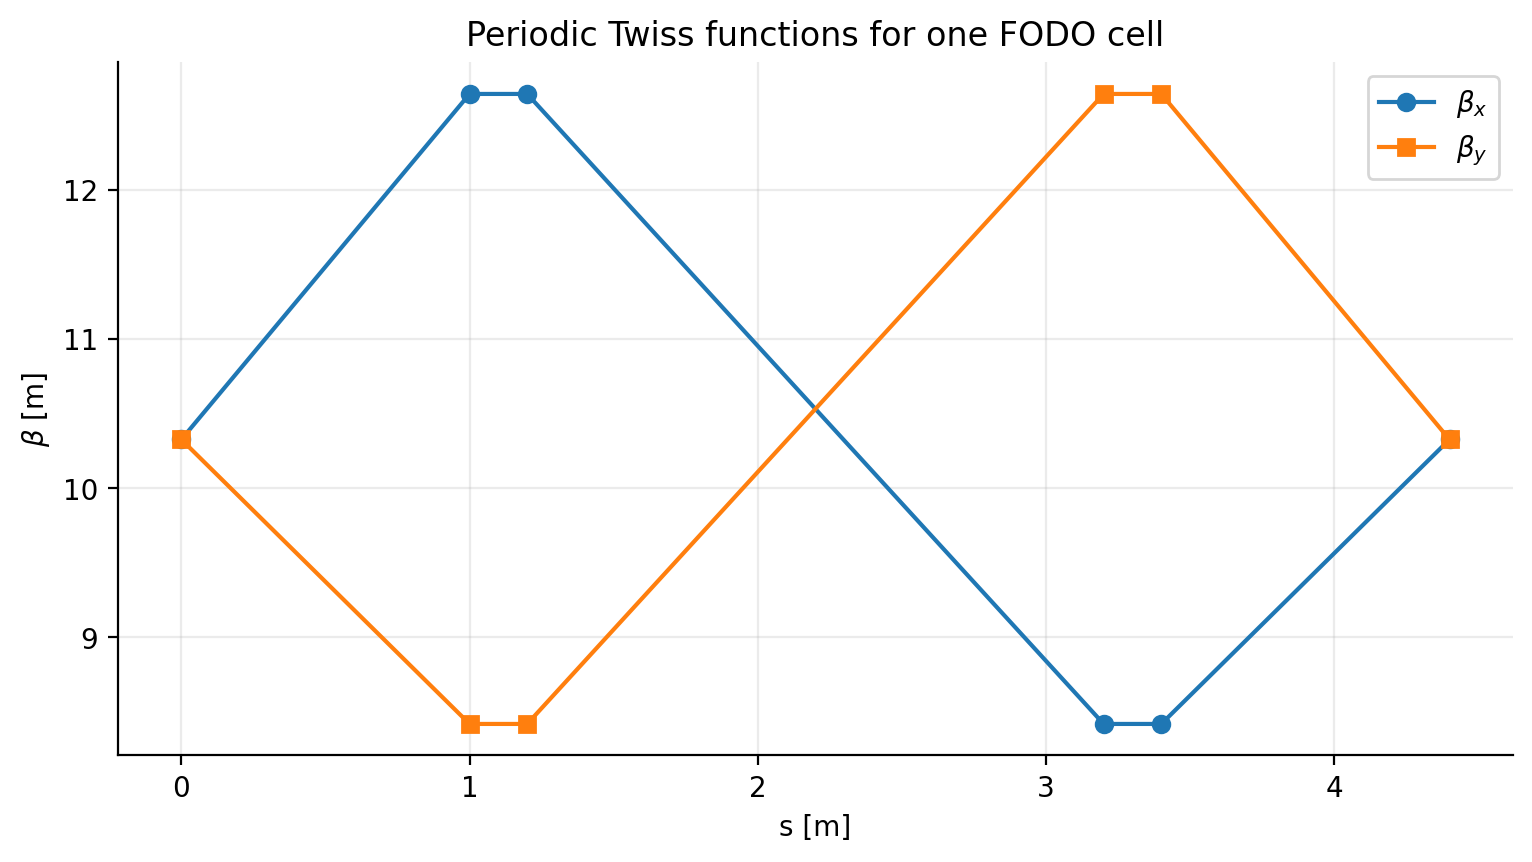

In [7]:
def plot_twiss(tw, title="Twiss functions"):
    fig, ax = plt.subplots()
    ax.plot(tw.s, tw.betx, marker="o", label=r"$\beta_x$")
    ax.plot(tw.s, tw.bety, marker="s", label=r"$\beta_y$")
    ax.set_xlabel("s [m]")
    ax.set_ylabel(r"$\beta$ [m]")
    ax.set_title(title)
    ax.legend()
    return fig, ax

plot_twiss(tw_cell, "Periodic Twiss functions for one FODO cell");


## 4. Change Quadrupole Strengths

Because the quadrupoles are connected to variables, changing `cell.vars["kqf"]` or `cell.vars["kqd"]` updates the magnets. Below we make the quadrupoles stronger and compare the resulting phase advance and beta functions.

In [8]:
cell_stronger = make_fodo_line(n_cells=1, kqf=1.35, kqd=-1.35)
tw_stronger = cell_stronger.twiss(method="4d")

comparison = pd.DataFrame({
    "case": ["original", "stronger quads"],
    "kqf [1/m^2]": [cell.vars["kqf"]._value, cell_stronger.vars["kqf"]._value],
    "kqd [1/m^2]": [cell.vars["kqd"]._value, cell_stronger.vars["kqd"]._value],
    "Qx per cell": [tw_cell.qx, tw_stronger.qx],
    "Qy per cell": [tw_cell.qy, tw_stronger.qy],
    "phase x [deg]": [360 * tw_cell.qx, 360 * tw_stronger.qx],
    "phase y [deg]": [360 * tw_cell.qy, 360 * tw_stronger.qy],
})
comparison


,case,kqf [1/m^2],kqd [1/m^2],Qx per cell,Qy per cell,phase x [deg],phase y [deg]
0,original,1.00,-1.00,0.068398,0.068398,24.623104,24.623104
1,stronger quads,1.35,-1.35,0.092942,0.092942,33.459163,33.459163


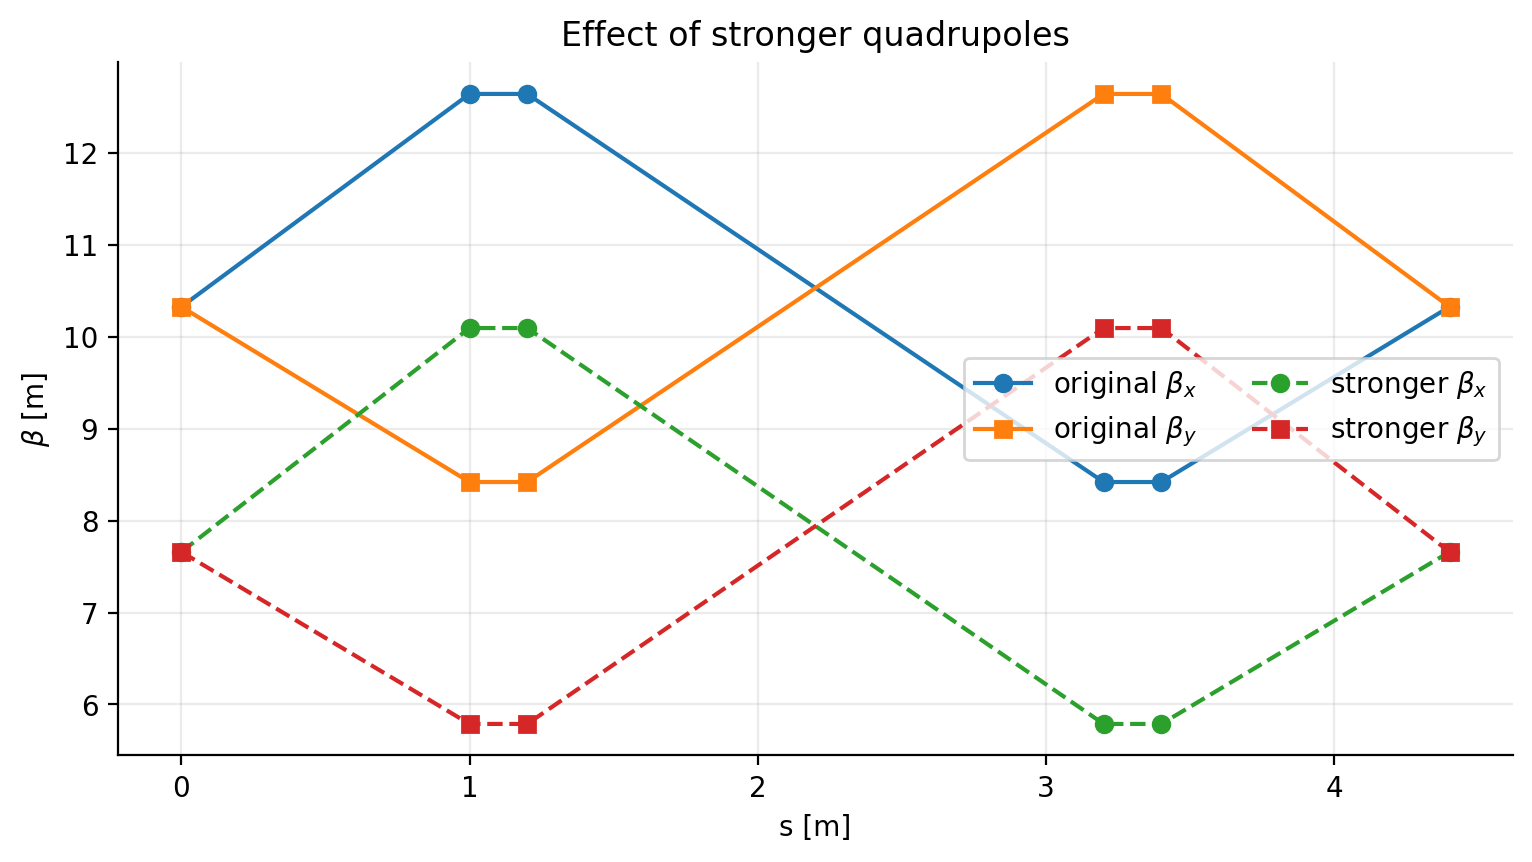

In [9]:
fig, ax = plt.subplots()
ax.plot(tw_cell.s, tw_cell.betx, "o-", label=r"original $\beta_x$")
ax.plot(tw_cell.s, tw_cell.bety, "s-", label=r"original $\beta_y$")
ax.plot(tw_stronger.s, tw_stronger.betx, "o--", label=r"stronger $\beta_x$")
ax.plot(tw_stronger.s, tw_stronger.bety, "s--", label=r"stronger $\beta_y$")
ax.set_xlabel("s [m]")
ax.set_ylabel(r"$\beta$ [m]")
ax.set_title("Effect of stronger quadrupoles")
ax.legend(ncol=2);


## 5. Two FODO Cells

Now repeat the same cell twice. The total tune of the two-cell line is twice the tune per cell if the cells are identical and periodic.

In [10]:
two_cells = make_fodo_line(n_cells=2, kqf=1.0, kqd=-1.0)
tw_two = two_cells.twiss(method="4d")

pd.DataFrame({
    "quantity": ["line length [m]", "Qx over two cells", "Qy over two cells", "phase x [deg]", "phase y [deg]"],
    "value": [tw_two.s[-1], tw_two.qx, tw_two.qy, 360 * tw_two.qx, 360 * tw_two.qy],
})


,quantity,value
0,line length [m],8.800000
1,Qx over two cells,0.136795
2,Qy over two cells,0.136795
3,phase x [deg],49.246209
4,phase y [deg],49.246209


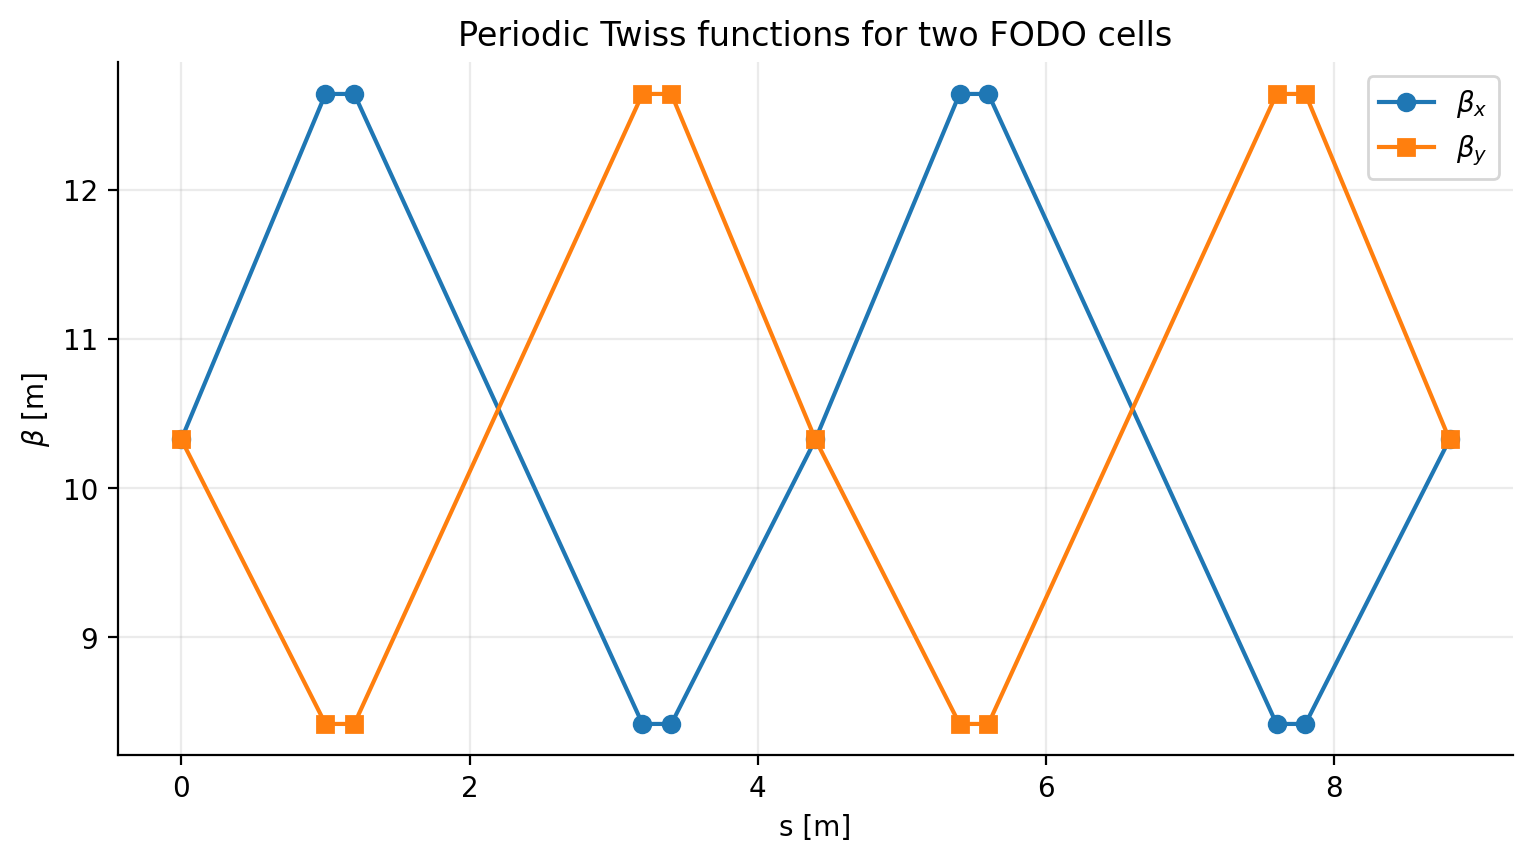

In [11]:
plot_twiss(tw_two, "Periodic Twiss functions for two FODO cells");


## 6. Match Two FODO Cells

Matching means adjusting knobs until optics targets are reached. In this example we vary the shared quadrupole strengths `kqf` and `kqd` and ask for a total two-cell phase advance of 90 degrees in both planes:

\[
Q_x = Q_y = \frac{90^\circ}{360^\circ} = 0.25.
\]

This corresponds to 45 degrees per FODO cell for this two-cell line.

In [12]:
matched = make_fodo_line(n_cells=2, kqf=1.0, kqd=-1.0)

opt = matched.match(
    method="4d",
    vary=[
        xt.Vary("kqf", step=1e-3),
        xt.Vary("kqd", step=1e-3),
    ],
    targets=[
        xt.Target("qx", 0.25, tol=1e-7),
        xt.Target("qy", 0.25, tol=1e-7),
    ],
)

tw_matched = matched.twiss(method="4d")

pd.DataFrame({
    "quantity": ["matched kqf [1/m^2]", "matched kqd [1/m^2]", "Qx", "Qy", "phase x [deg]", "phase y [deg]"],
    "value": [
        matched.vars["kqf"]._value,
        matched.vars["kqd"]._value,
        tw_matched.qx,
        tw_matched.qy,
        360 * tw_matched.qx,
        360 * tw_matched.qy,
    ],
})


                                             
Optimize - start penalty: 1.601                             
Matching: model call n. 13 penalty = 2.8892e-08              
Optimize - end penalty:  2.8892e-08                            


,quantity,value
0,matched kqf [1/m^2],1.794753
1,matched kqd [1/m^2],-1.794753
2,Qx,0.250000
3,Qy,0.250000
4,phase x [deg],90.000000
5,phase y [deg],90.000001


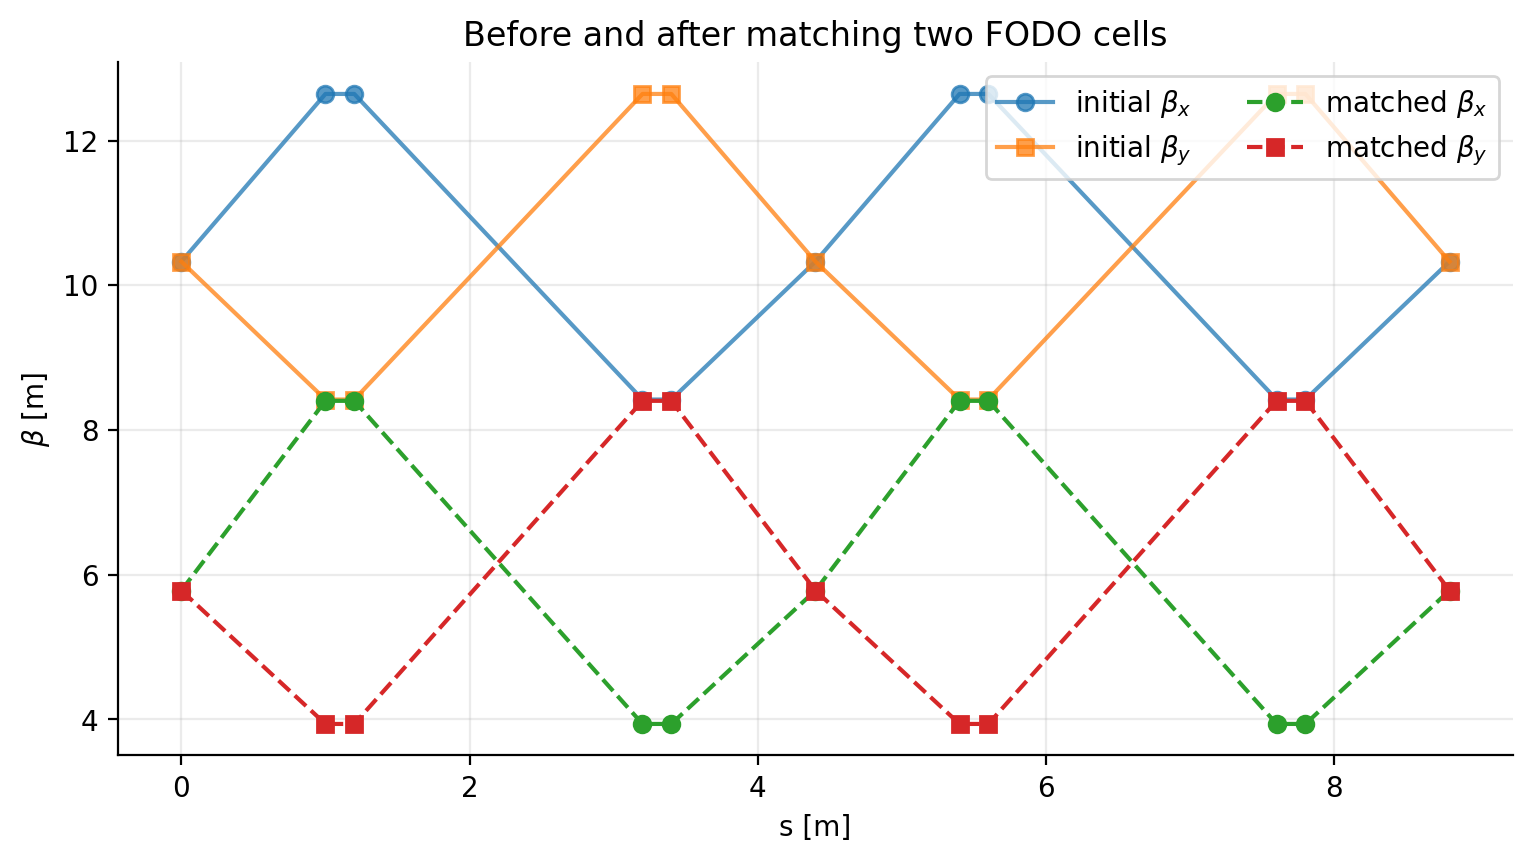

In [13]:
fig, ax = plt.subplots()
ax.plot(tw_two.s, tw_two.betx, "o-", alpha=0.75, label=r"initial $\beta_x$")
ax.plot(tw_two.s, tw_two.bety, "s-", alpha=0.75, label=r"initial $\beta_y$")
ax.plot(tw_matched.s, tw_matched.betx, "o--", label=r"matched $\beta_x$")
ax.plot(tw_matched.s, tw_matched.bety, "s--", label=r"matched $\beta_y$")
ax.set_xlabel("s [m]")
ax.set_ylabel(r"$\beta$ [m]")
ax.set_title("Before and after matching two FODO cells")
ax.legend(ncol=2);


## 7. Matched Beam Size From Twiss Parameters

Once we know \(\beta_x\) and \(\beta_y\), the RMS beam size for geometric emittance \(\epsilon\) is

\[
\sigma = \sqrt{\beta \epsilon}.
\]

The cell below uses a sample geometric emittance of 1 mm mrad.

In [14]:
emit_x = 1e-6  # 1 mm mrad = 1e-6 m rad
emit_y = 1e-6

beam_size = pd.DataFrame({
    "name": tw_matched.name,
    "s [m]": tw_matched.s,
    "sigma_x [mm]": 1e3 * np.sqrt(tw_matched.betx * emit_x),
    "sigma_y [mm]": 1e3 * np.sqrt(tw_matched.bety * emit_y),
})
beam_size


,name,s [m],sigma_x [mm],sigma_y [mm]
0,d1_c1,0.0,2.404223,2.404223
1,qf_c1,1.0,2.898658,1.983878
2,d2_c1,1.2,2.898658,1.983878
3,qd_c1,3.2,1.983878,2.898658
4,d3_c1,3.4,1.983878,2.898658
5,d1_c2,4.4,2.404223,2.404223
6,qf_c2,5.4,2.898658,1.983878
7,d2_c2,5.6,2.898658,1.983878
8,qd_c2,7.6,1.983878,2.898658
9,d3_c2,7.8,1.983878,2.898658


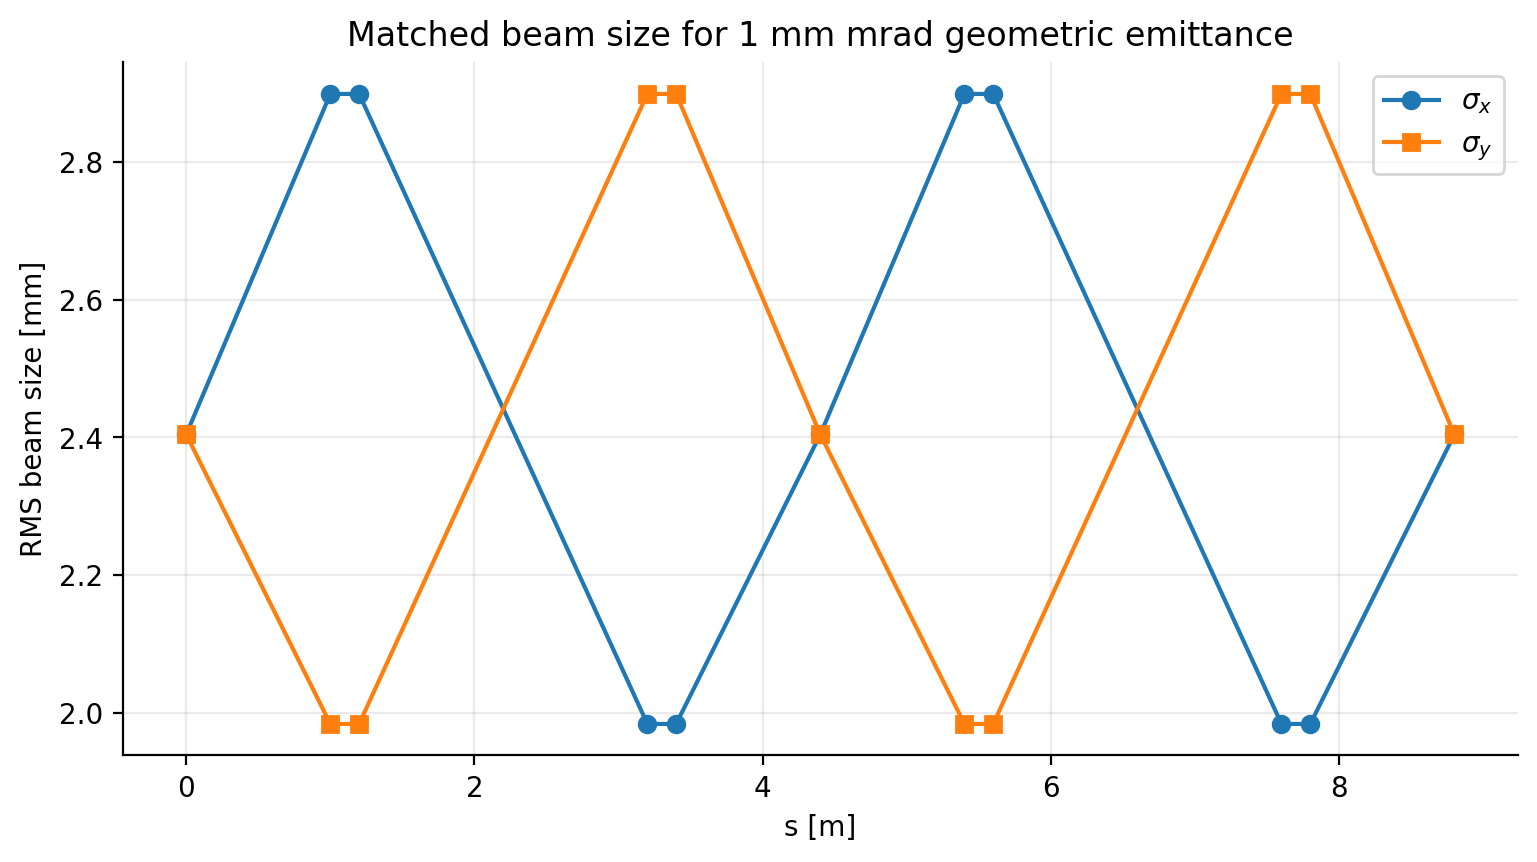

In [15]:
fig, ax = plt.subplots()
ax.plot(beam_size["s [m]"], beam_size["sigma_x [mm]"], "o-", label=r"$\sigma_x$")
ax.plot(beam_size["s [m]"], beam_size["sigma_y [mm]"], "s-", label=r"$\sigma_y$")
ax.set_xlabel("s [m]")
ax.set_ylabel("RMS beam size [mm]")
ax.set_title("Matched beam size for 1 mm mrad geometric emittance")
ax.legend();


## 8. Track a Few Particles

Finally, track a few test particles through the matched two-cell line. A stable matched lattice should transport small-amplitude particles without explosive growth.

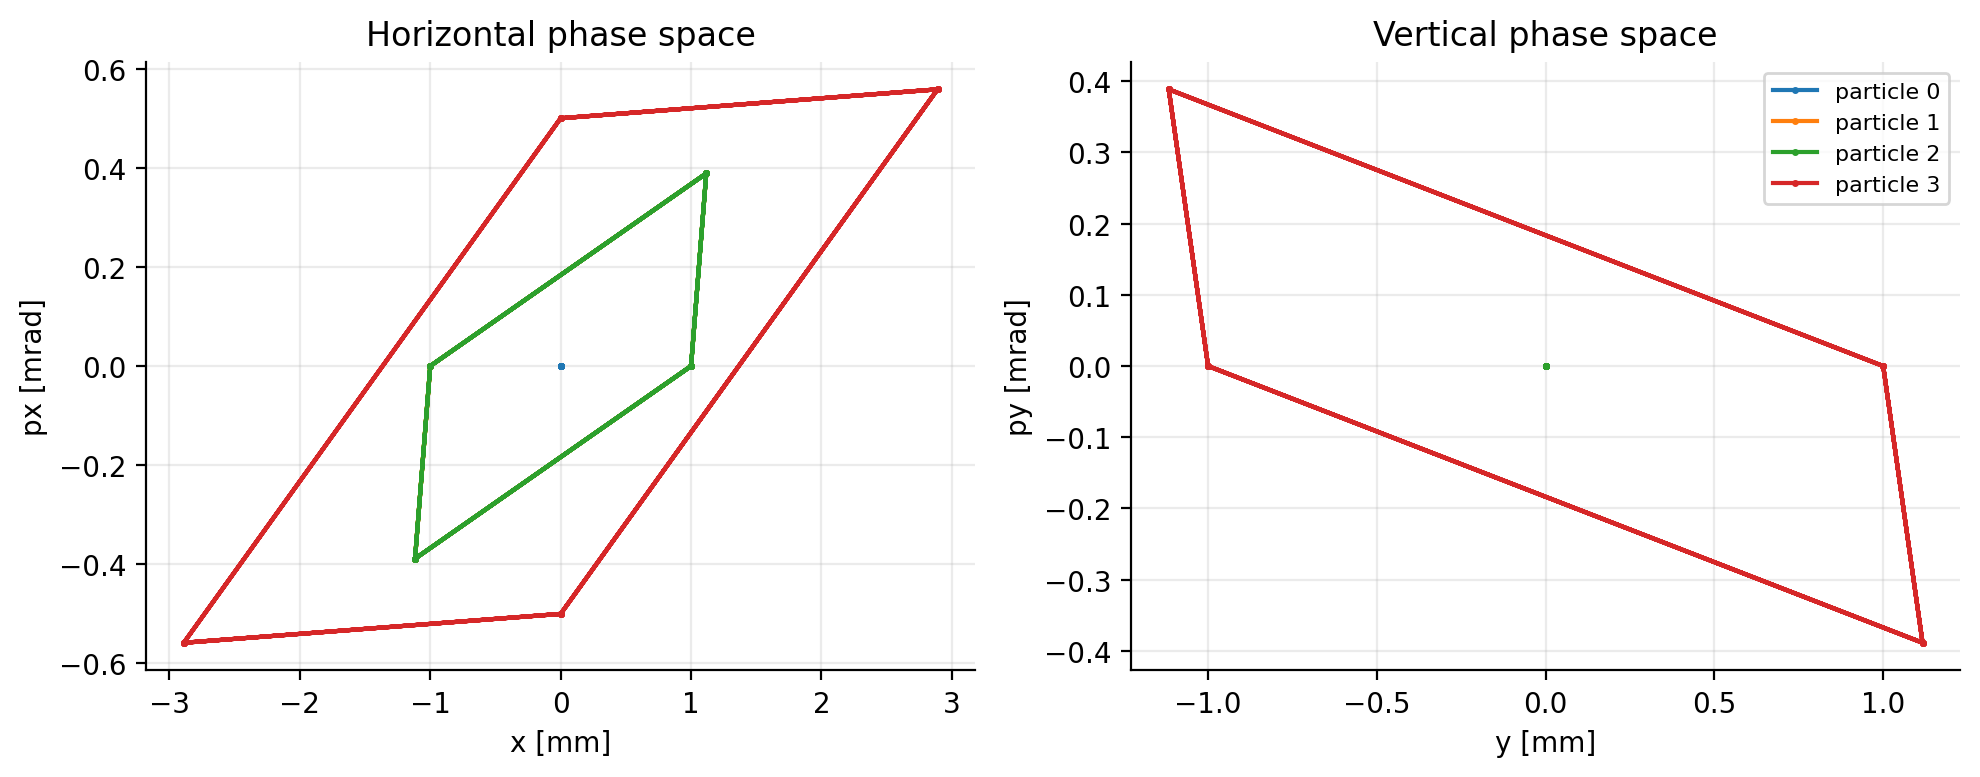

In [16]:
particles = matched.build_particles(
    x=[0.0, 1e-3, -1e-3, 0.0],
    px=[0.0, 0.0, 0.0, 0.5e-3],
    y=[0.0, 0.0, 0.0, 1e-3],
    py=[0.0, 0.0, 0.0, 0.0],
)

matched.track(particles, num_turns=20, turn_by_turn_monitor=True)
mon = matched.record_last_track

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i_particle in range(4):
    ax[0].plot(1e3 * mon.x[i_particle], 1e3 * mon.px[i_particle], ".-", ms=3, label=f"particle {i_particle}")
    ax[1].plot(1e3 * mon.y[i_particle], 1e3 * mon.py[i_particle], ".-", ms=3, label=f"particle {i_particle}")

ax[0].set_xlabel("x [mm]")
ax[0].set_ylabel("px [mrad]")
ax[0].set_title("Horizontal phase space")
ax[1].set_xlabel("y [mm]")
ax[1].set_ylabel("py [mrad]")
ax[1].set_title("Vertical phase space")
ax[1].legend(loc="best", fontsize=8)
fig.tight_layout();


## Exercises

1. Change the target phase advance in the matching cell from 90 degrees over two cells to 120 degrees. What happens to `kqf`, `kqd`, and the maximum beta functions?
2. Try unequal targets, for example `qx=0.22` and `qy=0.28`. Can this symmetric FODO lattice satisfy both targets with only `kqf` and `kqd`?
3. Increase the drift length and repeat the matching. How does the required quadrupole strength change?
4. Replace the proton reference particle with an electron reference particle. Which optics quantities change, and which stay the same when `k1` is fixed?
